In [1]:
# ՔԱՅԼ 1: ԳՐԱԴԱՐԱՆՆԵՐԻ ՆԵՐՄՈՒԾՈՒՄ, ՏՎՅԱԼՆԵՐ

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Հասանելի է {device}")

# 1. Data Augmentation և Normalization
transform_train = transforms.Compose([
    transforms.Resize((224, 224)), # ResNet-ի համար չափսը մեծացնում ենք
    transforms.RandomHorizontalFlip(), # հայելային շրջում
    transforms.RandomRotation(15),     # Պատահական պտույտ
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. CIFAR-10 տվյալների բեռնում
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# 3. DataLoader-ների ստեղծում
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Դասեր CIFAR-10-ում
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Մարզման տվյալների քանակը: {len(train_dataset)}")
print(f"Թեստավորման տվյալների քանակը: {len(test_dataset)}")

Օգտագործվում է սարքը: cuda


100%|██████████| 170M/170M [00:03<00:00, 44.1MB/s]


Մարզման տվյալների քանակը: 50000
Թեստավորման տվյալների քանակը: 10000


In [2]:
# ==========================================
# ՔԱՅԼ 2: ՄՈԴԵԼԻ ՍՏԵՂԾՈՒՄ (RESNET18 FINE-TUNING)
# ==========================================

import torchvision.models as models

# 1. Բեռնում ենք նախապես մարզված ResNet18 մոդելը
# weights=models.ResNet18_Weights.DEFAULT-ը ավտոմատ վերցնում է լավագույն ImageNet կշիռները
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 2. Փոխում ենք վերջին Fully Connected (fc) շերտը
# resnet18.fc.in_features-ը ցույց է տալիս, թե քանի մուտքային նեյրոն ունի վերջին շերտը (ResNet18-ի դեպքում՝ 512)
in_features = resnet18.fc.in_features

# Փոխարինում ենք նոր Linear շերտով՝ 10 ելքով (քանի որ CIFAR-10-ն ունի 10 դաս)
resnet18.fc = nn.Linear(in_features, 10)

# 3. Մոդելը տեղափոխում ենք GPU (cuda)
model = resnet18.to(device)

# Ստուգում ենք մոդելի կառուցվածքի վերջին մասը
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 196MB/s]


Linear(in_features=512, out_features=10, bias=True)


In [6]:
# ՔԱՅԼ 3: LOSS, OPTIMIZER and SCHEDULER

# 1. ստանդարտ Loss ֆունկցիա
criterion = nn.CrossEntropyLoss()

# 2. Hyperparameters
LEARNING_RATE = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
EPOCHS = 10

# 3. Optimizer
optimizer = optim.SGD(
    model.parameters(),
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

# 4. Learning Rate Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [5]:

# ՔԱՅԼ 4: ՄՈԴԵԼԻ ՄԱՐԶՈՒՄ ԵՎ ՎԱՎԵՐԱՑՈՒՄ (TRAINING LOOP)
import time

# Պահեստավորում ենք արդյունքները գրաֆիկների համար
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

print("Մարզման գործընթացը սկսված է... ")

for epoch in range(EPOCHS):
    start_time = time.time()

    # TRAIN PART
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device) # Տեղափոխում ենք GPU

        optimizer.zero_grad()

        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, labels) # Loss-ի հաշվարկ

        loss.backward() # Backward pass
        optimizer.step() # Կշիռների թարմացում

        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_train_acc = 100. * train_correct / train_total

    #  VALIDATION PART
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    epoch_val_loss = val_loss / len(test_loader.dataset)
    epoch_val_acc = 100. * val_correct / val_total

    # Թարմացնում ենք learning rate-ը
    scheduler.step()

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    elapsed_time = time.time() - start_time
    print(f"Epoch [{epoch+1}/{EPOCHS}] ({elapsed_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% || "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

print("\nՄարզումն ավարտվեց։")

Մարզման գործընթացը սկսված է... Սա կարող է տևել մի քանի րոպե:

Epoch [1/10] (189.5s) -> Train Loss: 0.4288 | Train Acc: 85.09% || Val Loss: 0.3415 | Val Acc: 88.39%
Epoch [2/10] (195.3s) -> Train Loss: 0.2297 | Train Acc: 92.05% || Val Loss: 0.2211 | Val Acc: 92.70%
Epoch [3/10] (197.7s) -> Train Loss: 0.1719 | Train Acc: 93.94% || Val Loss: 0.1885 | Val Acc: 93.73%
Epoch [4/10] (196.6s) -> Train Loss: 0.1196 | Train Acc: 95.81% || Val Loss: 0.1690 | Val Acc: 94.56%
Epoch [5/10] (197.2s) -> Train Loss: 0.0823 | Train Acc: 97.16% || Val Loss: 0.1655 | Val Acc: 94.65%
Epoch [6/10] (196.2s) -> Train Loss: 0.0520 | Train Acc: 98.28% || Val Loss: 0.1407 | Val Acc: 95.39%
Epoch [7/10] (196.8s) -> Train Loss: 0.0337 | Train Acc: 98.97% || Val Loss: 0.1230 | Val Acc: 96.19%
Epoch [8/10] (196.3s) -> Train Loss: 0.0220 | Train Acc: 99.36% || Val Loss: 0.1157 | Val Acc: 96.38%
Epoch [9/10] (196.8s) -> Train Loss: 0.0156 | Train Acc: 99.60% || Val Loss: 0.1145 | Val Acc: 96.46%
Epoch [10/10] (196.6

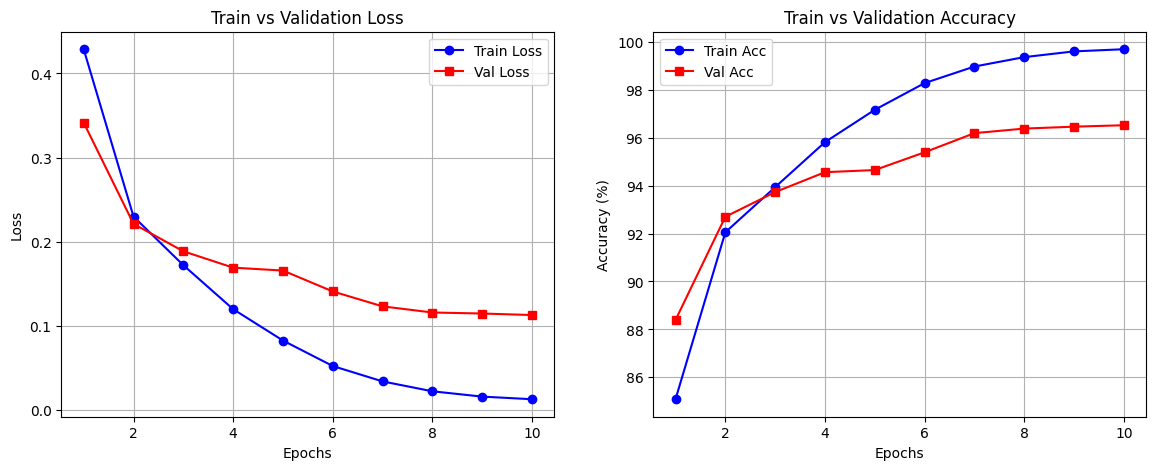


ՄՈԴԵԼԻ ԳՆԱՀԱՏՄԱՆ ՀԱՇՎԵՏՎՈՒԹՅՈՒՆ (CLASSIFICATION REPORT)
              precision    recall  f1-score   support

       plane     0.9662    0.9730    0.9696      1000
         car     0.9751    0.9800    0.9776      1000
        bird     0.9704    0.9500    0.9601      1000
         cat     0.9333    0.9240    0.9286      1000
        deer     0.9606    0.9750    0.9677      1000
         dog     0.9366    0.9450    0.9408      1000
        frog     0.9743    0.9840    0.9791      1000
       horse     0.9818    0.9730    0.9774      1000
        ship     0.9750    0.9770    0.9760      1000
       truck     0.9788    0.9710    0.9749      1000

    accuracy                         0.9652     10000
   macro avg     0.9652    0.9652    0.9652     10000
weighted avg     0.9652    0.9652    0.9652     10000



In [7]:
# ՔԱՅԼ 5: ԳՐԱՖԻԿՆԵՐ

from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# 1. Loss և Accuracy
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5))

# Loss-ի գրաֆիկը
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Val Loss', color='red', marker='s')
plt.title('Train vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy-ի գրաֆիկը
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Train Acc', color='blue', marker='o')
plt.plot(epochs_range, history['val_acc'], label='Val Acc', color='red', marker='s')
plt.title('Train vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.show()

# 2. Լրացուցիչ մետրիկաների հաշվարկ ամբողջ թեստային բազայի համար
model.look_ahead = False
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n" + "="*60)
print("ՄՈԴԵԼԻ ԳՆԱՀԱՏՄԱՆ ՀԱՇՎԵՏՎՈՒԹՅՈՒՆ (CLASSIFICATION REPORT)")
print("="*60)
print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

Մոդելը հաջողությամբ պահպանվեց 'resnet18_cifar10.pth'

Սկսում ենք Inference-ի ստուգումը
Մոդելը հաջողությամբ բեռնվեց։


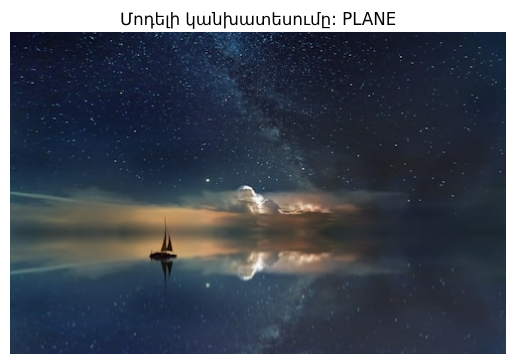

In [9]:
# ՔԱՅԼ 6 և 7: ՄՈԴԵԼԻ ՊԱՀՊԱՆՈՒՄ ԵՎ INFERENCE

import requests
from PIL import Image

# 1.Մոդելի կշիռները պահում ենք
MODEL_PATH = "resnet18_cifar10.pth"
torch.save(model.state_dict(), MODEL_PATH)
print(f"Մոդելը հաջողությամբ պահպանվեց '{MODEL_PATH}'")

print("\nՍկսում ենք Inference-ի ստուգումը")

# 2. ԲԵՌՆՈՒՄ (Load)
loaded_model = models.resnet18()
loaded_model.fc = nn.Linear(loaded_model.fc.in_features, 10)
loaded_model.load_state_dict(torch.load(MODEL_PATH))
loaded_model = loaded_model.to(device)
loaded_model.eval()
print("Մոդելը հաջողությամբ բեռնվեց։")

# 3. ՆՈՐ ՆԿԱՐԻ ՆԵՐԲԵՌՆՈՒՄ ՀԱՄԱՑԱՆՑԻՑ
img_url = "https://images.unsplash.com/photo-1534447677768-be436bb09401?w=500"
img_raw = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')

# 4. ՏՐԱՆՍՖՈՐՄԱՑԻԱ
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

img_tensor = inference_transform(img_raw).unsqueeze(0).to(device) # unsqueeze-ով ավելացնում ենք batch չափսը

# 5. ԿԱՆԽԱՏԵՍՈՒՄ (Prediction)
with torch.no_grad():
    outputs = loaded_model(img_tensor)
    _, predicted = outputs.max(1)
    predicted_class = classes[predicted.item()]

# 6. ԱՐԴՅՈՒՆՔԻ ՑՈՒՑԱԴՐՈՒՄ
plt.imshow(img_raw)
plt.title(f"Մոդելի կանխատեսումը: {predicted_class.upper()}")
plt.axis('off')
plt.show()